In [1]:
import matplotlib.pyplot as plt
import torch

from pi_solvers import sde_lib, solver_lib, utils

torch.manual_seed(42)

In [2]:
edm = solver_lib.get_edm_schedule(25)
edm < 1

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True])

In [3]:
model, encoder = utils.load_edm_checkpoint("../model/edm2-img64-xl-0671088-0.040.pkl")
model = model.to("cuda")

In [4]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = torch.randn_like(x) * 80

In [5]:
labels = torch.eye(model.label_dim, device="cuda")[torch.randint(high=model.label_dim, size=(16,), device="cuda")]

In [6]:
sigma_min = 0.002
sigma_max = 80

sde_ = sde_lib.EDMSDE(ode=False).to("cuda")
rsde = sde_.get_reverse_sde(model, ode_threshold=0.05).to("cuda")

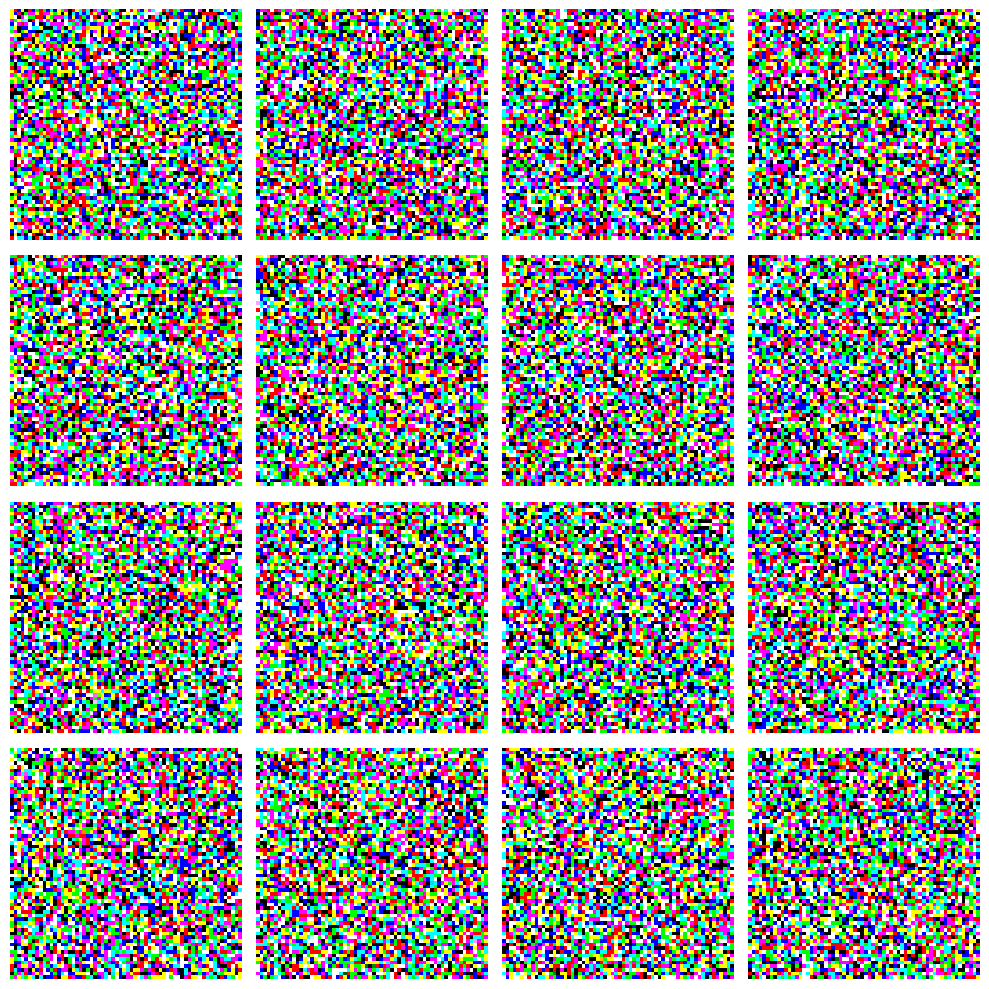

In [7]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [68]:
n_steps = 75
rho = 7
# From EDM2 code
# discretisation = solver_lib.get_edm_schedule(25, sigma_min, sigma_max, rho)
# discretisation = solver_lib.get_entropy_schedule(n_steps, entropy_checkpoint="../refs/img64_rescaled_entropic_time.pt")
discretisation = solver_lib.get_pi_schedule(31, 0, "../data/image_testing/pi_2/75NFE_2/data/_t.csv")

In [69]:
discretisation

tensor([7.9975e+01, 3.9667e+01, 2.6107e+01, 1.7764e+01, 1.2753e+01, 9.4789e+00,
        7.2370e+00, 5.6349e+00, 4.4515e+00, 3.5542e+00, 2.8602e+00, 2.3149e+00,
        1.8814e+00, 1.5337e+00, 1.2529e+00, 1.0249e+00, 8.3921e-01, 6.8743e-01,
        5.6311e-01, 4.6111e-01, 3.7735e-01, 3.0850e-01, 2.5188e-01, 2.0531e-01,
        1.6701e-01, 1.3550e-01, 1.0960e-01, 8.8319e-02, 7.0837e-02, 5.6493e-02],
       dtype=torch.float64)

In [32]:
rsde.reset()

em_solver = solver_lib.HeunSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone(), labels)

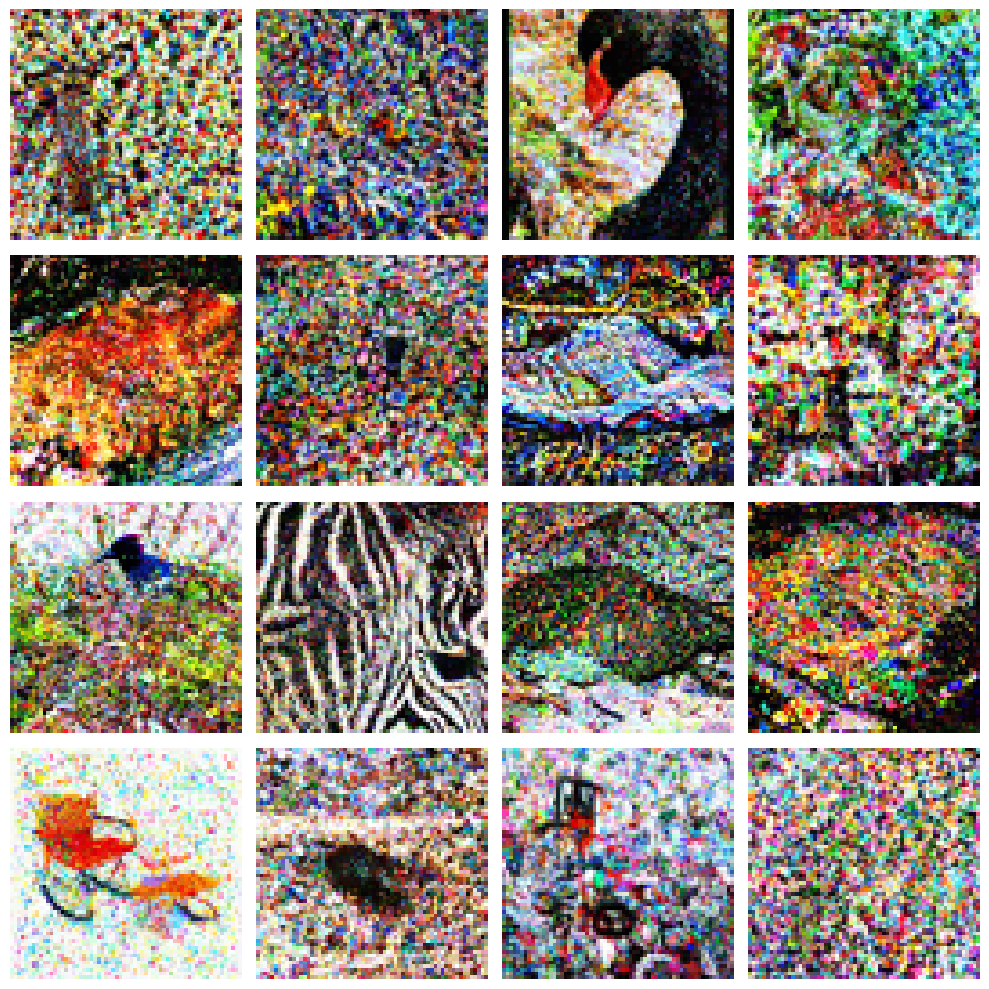

In [33]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [9]:
sigmas = []
sigmas_std = []
trajectories = []
def pi_callback(x, t, h, error):    
    print(f"sigma = {torch.mean(t)}", end=" ")
    print(f"h = {torch.mean(h)}", end=" ")
    print(f"error = {torch.mean(error)}")
    sigmas.append(torch.mean(t).cpu())
    sigmas_std.append(torch.std(t).cpu())
    trajectories.append(t[0:2].clone())

In [105]:
sigmas = [80]
sigmas_std = [0]
trajectories = []

rsde.reset()

pi_solver = solver_lib.construct_heun_end_adaptive_solver(
    solver_lib.PISolver,
    rsde,
    ode_threshold=0.05,
    n_ode_steps=5,
    ki=0.3,
    kp=0.1, 
    tau_a=0.001,
    tau_r=80,
    alpha=0.9,
    h_start=40,
    max_decrease=0.7,
    max_increase=1.3,
    interval=(80, 0.002),
    abs_error=False,
    batch_norm=False
).to("cuda")

x_pi = pi_solver.solve(noise.clone(), labels, callback=pi_callback)

sigma = 40.0 h = -28.0 error = 0.151556134223938
sigma = 12.0 h = -11.949999809265137 error = 0.4200858473777771
sigma = 12.0 h = -8.364999771118164 error = 13.965129852294922
sigma = 12.0 h = -5.855499744415283 error = 1.4989385604858398
sigma = 6.144500255584717 h = -4.098849773406982 error = 0.4414023160934448
sigma = 6.144500255584717 h = -2.869194746017456 error = 1.1939945220947266
sigma = 3.2753055095672607 h = -2.0084362030029297 error = 0.3747117519378662
sigma = 1.266869306564331 h = -1.2168693542480469 error = 0.7768425941467285
sigma = 1.266869306564331 h = -0.8518085479736328 error = 4.378002643585205
sigma = 0.41506075859069824 h = -0.3650607466697693 error = 0.1341906189918518
sigma = 0.050000011920928955 h = -1.1175870895385742e-08 error = 0.37314727902412415
sigma = 0.05000000074505806 h = 0.0 error = 6.516043260518245e-09


KeyboardInterrupt: 

In [102]:
rsde.nfe / 16

29.0

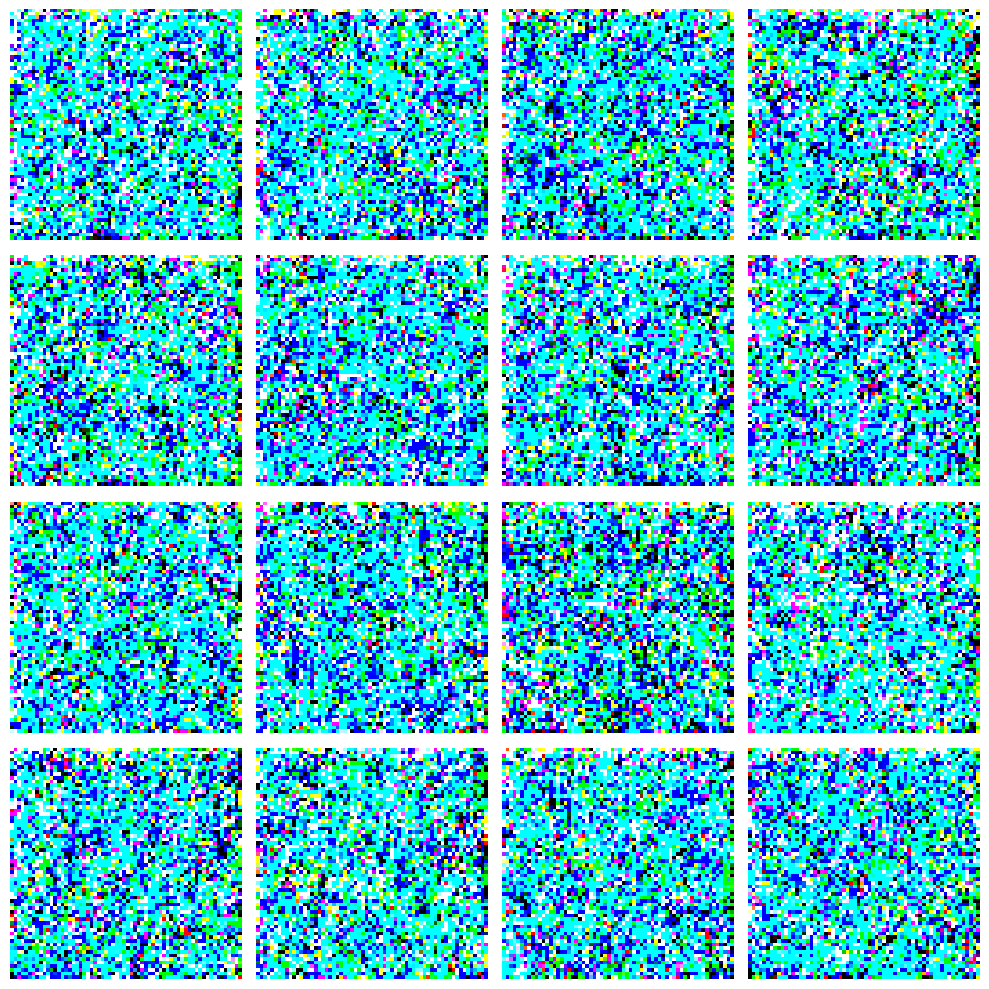

In [103]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())

In [13]:
sigmas = [80]
sigmas_std = [0]
trajectories = []

rsde.reset()

ggf_solver = solver_lib.construct_heun_end_adaptive_solver(
    solver_lib.GottaGoFast,
    rsde,
    ode_threshold=0.05,
    n_ode_steps=5,
    tau_a=0.0078,   # Range is -1, 1, which is mentioned in paper to correspond to a tau_a of (1 -- 1 / 256 = 0.0078)
    tau_r=24.5,
    h_start=25,
    r=0.1,
    alpha=0.7,
    interval=(80, 0.002)
).to("cuda")

x_ggf = ggf_solver.solve(noise.clone(), labels, pi_callback)

sigma = 55.0 h = -19.415489196777344 error = 0.3539227843284607
sigma = 35.584510803222656 h = -14.12447738647461 error = 0.6855530142784119
sigma = 25.88231658935547 h = -9.847463607788086 error = 1.309314250946045
sigma = 22.912254333496094 h = -6.888328552246094 error = 1.3698618412017822
sigma = 16.93520736694336 h = -5.145056247711182 error = 0.6043568849563599
sigma = 11.790153503417969 h = -3.9233248233795166 error = 0.4621601104736328
sigma = 8.094215393066406 h = -2.9145898818969727 error = 0.6841020584106445
sigma = 6.527488708496094 h = -2.1104001998901367 error = 0.9668662548065186
sigma = 4.846859931945801 h = -1.5634231567382812 error = 0.6758662462234497
sigma = 3.3703508377075195 h = -1.1806561946868896 error = 0.5369836091995239
sigma = 2.340519428253174 h = -0.8656793236732483 error = 0.6880007982254028
sigma = 1.8468809127807617 h = -0.6135271191596985 error = 1.0941871404647827
sigma = 1.30655837059021 h = -0.4513375759124756 error = 0.6707204580307007
sigma = 0.954

In [14]:
rsde.nfe / 16

49.75

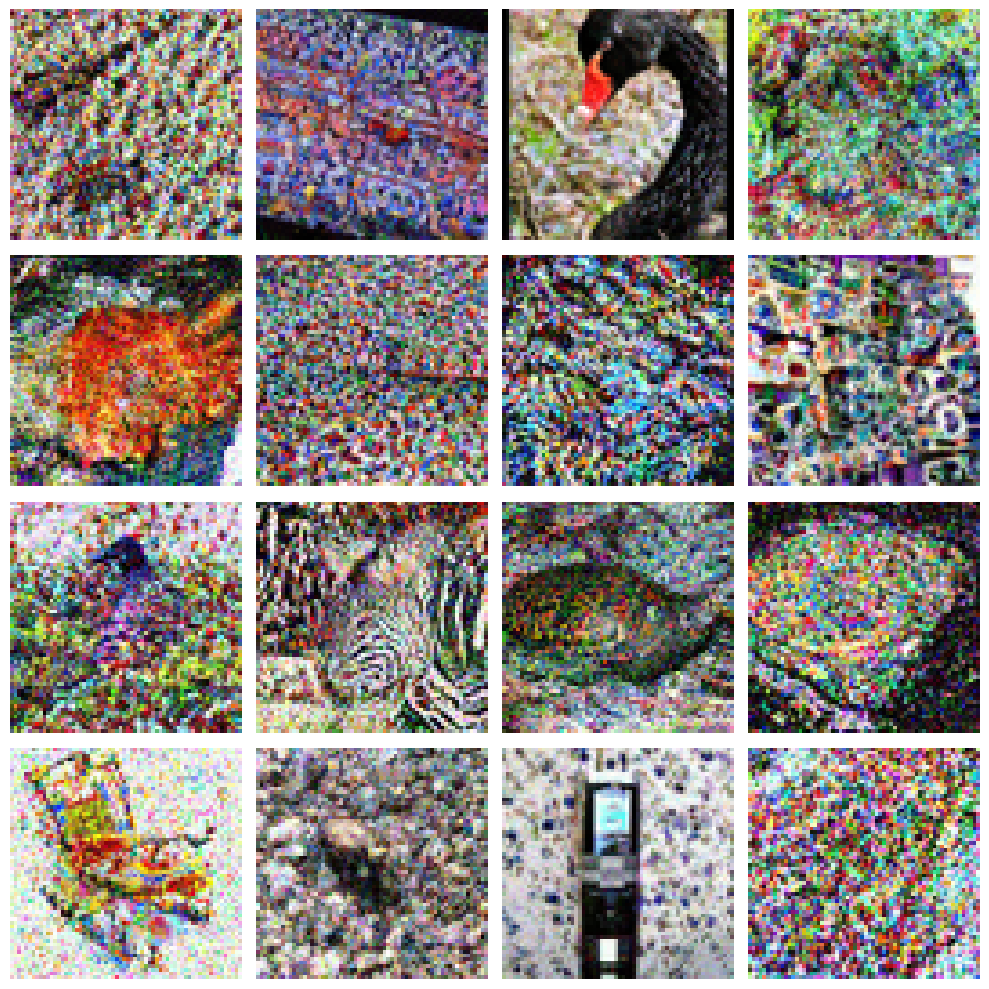

In [15]:
images = encoder.decode(x_ggf).permute(0, 2, 3, 1)
plot_images(images.cpu())

In [94]:
edm_schedule = solver_lib.get_edm_schedule(100)

In [95]:
trajectory_1 = []
trajectory_2 = []
for element in trajectories:
    trajectory_1.append(element[0, 0, 0].cpu())
    trajectory_2.append(element[1, 0, 0].cpu())

trajectory_1 = torch.cat([torch.tensor([80]), torch.cat(trajectory_1)])
trajectory_2 = torch.cat([torch.tensor([80]), torch.cat(trajectory_2)])

trajectory_1 = trajectory_1[trajectory_1 > 0.05]
trajectory_2 = trajectory_2[trajectory_2 > 0.05]
discretisation = discretisation[discretisation > 0.05]
edm_schedule = edm_schedule[edm_schedule > 0.05]

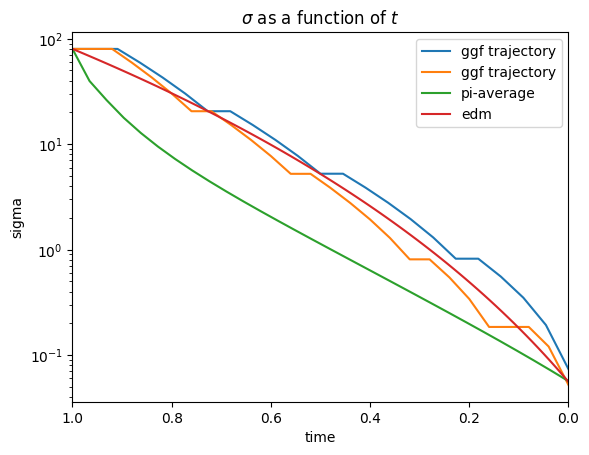

In [96]:
plt.title(r"$\sigma$ as a function of $t$")
plt.plot(torch.linspace(1, 0, len(trajectory_1)), trajectory_1.cpu(), label="ggf trajectory")
plt.plot(torch.linspace(1, 0, len(trajectory_2)), trajectory_2.cpu(), label="ggf trajectory")

# plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas) + torch.tensor(sigmas_std)))
# plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas) - torch.tensor(sigmas_std)))
plt.plot(torch.linspace(1, 0, len(discretisation)), discretisation, label="pi-average")
plt.plot(torch.linspace(1, 0, len(edm_schedule)), edm_schedule, label="edm")

plt.legend()
plt.xlim(1, 0)
plt.xlabel("time")
plt.ylabel("sigma")
plt.yscale("log")

In [10]:
edm_solver = solver_lib.EDMSolver(discretisation, model,S_churn=40, S_min=0.05, S_max=50, S_noise=1.003).to("cuda")
x_edm = edm_solver.solve(noise.clone(), labels)

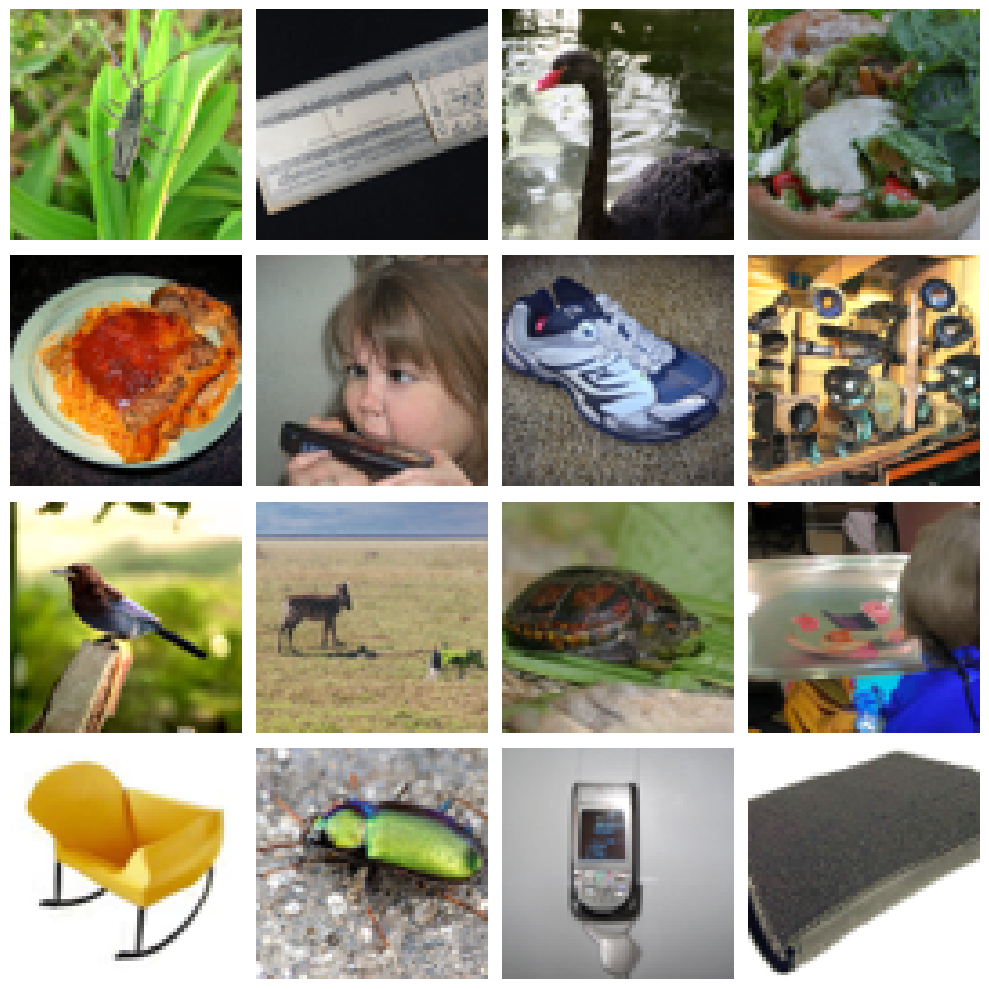

In [11]:
images = encoder.decode(x_edm).permute(0, 2, 3, 1)
plot_images(images.cpu())